# Course project

This notebook includes the code for the course project in the DTU course [Integrated Energy Grids](https://kurser.dtu.dk/course/2024-2025/46770?menulanguage=en)  and is modelling and analyzing the german energy system. 
 
The report is provided along this notebook, further explaining the results. 

### Imports

In [1]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

import base  # now you can use base.build_network()
from visualization import *

In [3]:
country = "DEU"

## D. Introducing Storage Technology 
Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies is your system using to balance the renewable generation at different time scales (intraday, seasonal, etc.)


### Adding Fixed Storage Unit

In [4]:
n_batt_fixed = base.build_network(solve=False)

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


In [5]:
costs = base.load_technology_data()

In [6]:
# add battery
storage_unit_e2p = 2

n_batt_fixed.add(
    "StorageUnit",
    "battery storage 2",
    bus=f"{country}_elec",
    carrier="battery storage",
    max_hours=storage_unit_e2p,
    capital_cost=costs.at["battery inverter", "capital_cost"]
    + storage_unit_e2p * costs.at["battery storage", "capital_cost"],
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
    overwrite=True
)


Index(['battery storage 2'], dtype='object')

In [7]:
n_batt_fixed.optimize(solver_name="gurobi")

Index(['battery storage 2'], dtype='object', name='StorageUnit')


Index(['DEU_elec'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 37.76it/s]
INFO:linopy.io: Writing time: 0.85s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2625590


...

Solved in 16610 iterations and 2.92 seconds (3.35 work units)


INFO:gurobipy:Solved in 16610 iterations and 2.92 seconds (3.35 work units)


Optimal objective  3.161903000e+10


INFO:gurobipy:Optimal objective  3.161903000e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 96369 primals, 210254 duals
Objective: 3.16e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

System Cost: 31.62 billion euros

Optimal Generator and Storage Capacities (GW):
coal                 11.004848
lignite              21.000000
biomass CHP          10.000000
OCGT                 31.000000
ror                   0.000000
onwind                2.889546
offwind               2.070250
solar                14.887529
battery storage 2     4.043076
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
coal                  86.297878
lignite              183.129720
biomass CHP           87.600000
OCGT                 121.237974
ror                    0.000000
onwind                 5.341877
offwind                6.521299
solar                 15.350874
battery storage 2     -0.215059
dtype: float64


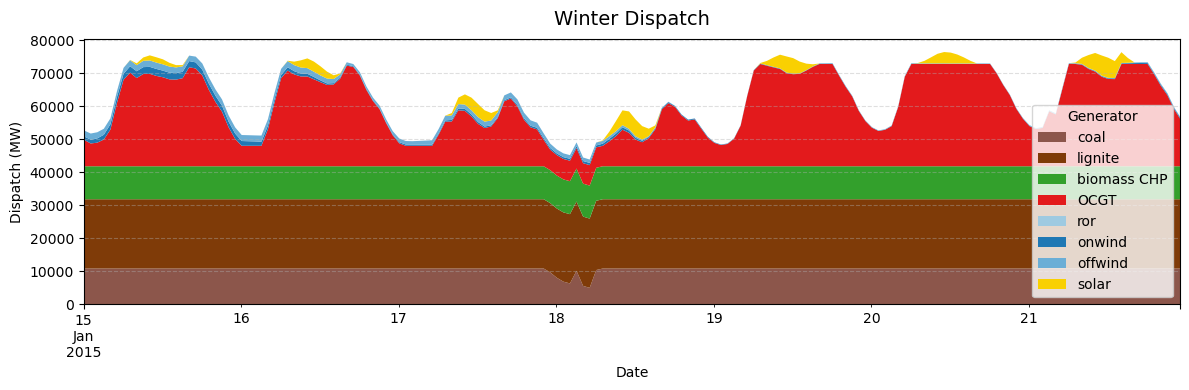

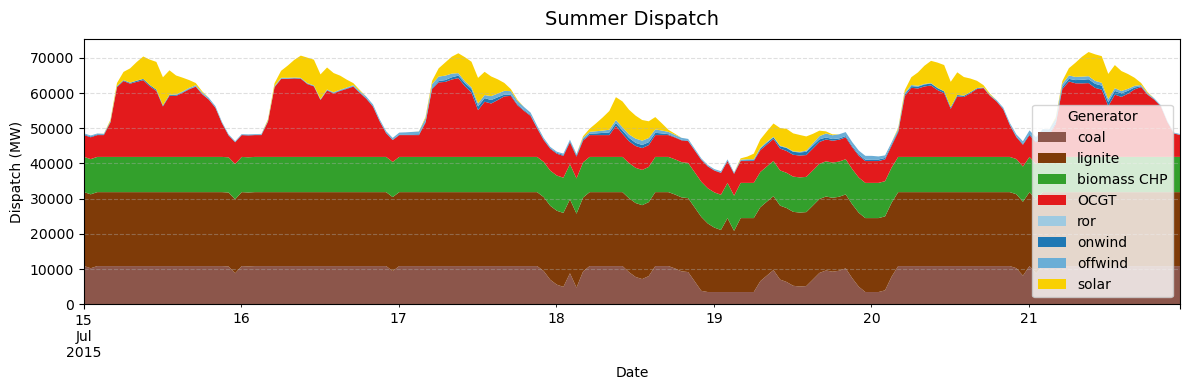

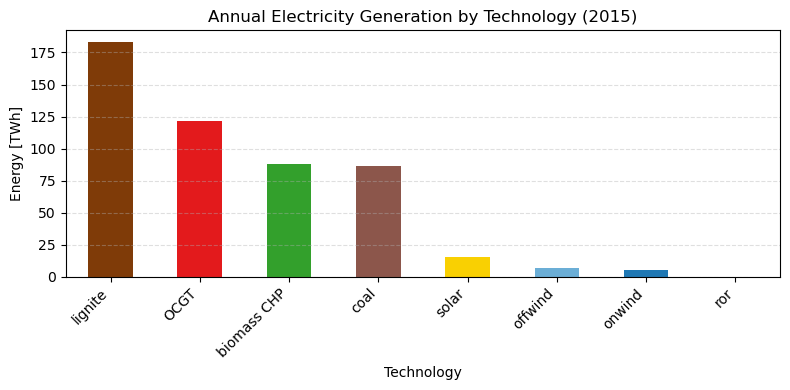

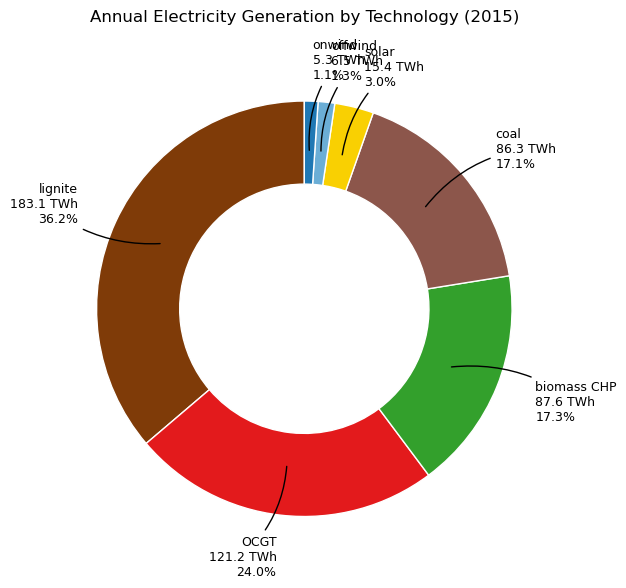

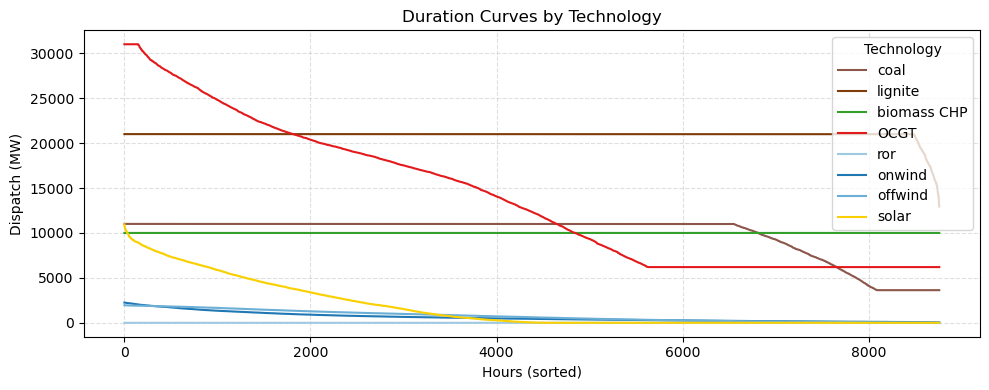

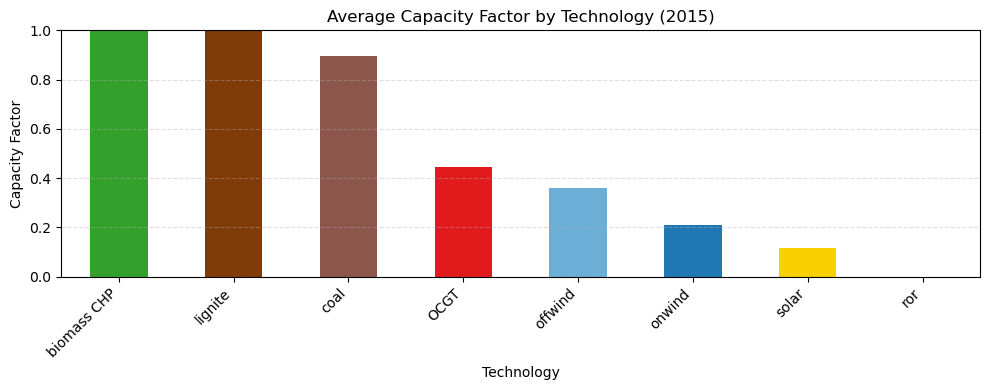

In [8]:
print_summary(n_batt_fixed)
# Plot winter week
plot_dispatch_week(n_batt_fixed, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
plot_dispatch_week(n_batt_fixed,"2015-07-15", "2015-07-21", "Summer Dispatch")
plot_generation_bar(n_batt_fixed)
plot_generation_pie(n_batt_fixed)
plot_duration_curves(n_batt_fixed)
plot_capacity_factors(n_batt_fixed)

<Axes: xlabel='snapshot', ylabel='battery'>

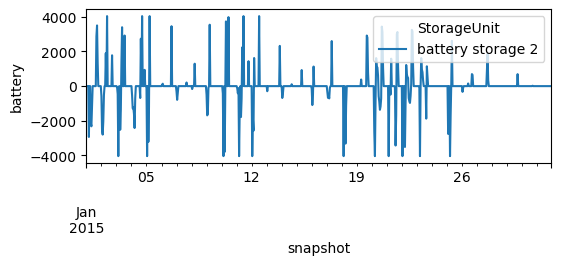

In [9]:
n_batt_fixed.storage_units_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="battery")

### Adding Battery as Store with Links

In [10]:
n_batt_store = base.build_network(solve=False)

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


In [11]:
def annuity(r, n):
       return r / (1 - 1 / (1 + r)**n) if r > 0 else 1 / n

In [12]:
# battery store + link

#Create a new bus
n_batt_store.add("Bus",
          "elec_store",
          carrier = "battery storage",
          overwrite=True)

#Connect the store to the bus
n_batt_store.add("Store",
          "Battery Storage Store",
          bus = "elec_store",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = costs.at["battery storage", "capital_cost"],
          overwrite=True)

n_batt_store.add("Link",
          "grid to battergy storage",
          bus0 = f"{country}_elec",
          bus1 = "elec_store",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True)

n_batt_store.add("Link",
          "battery storage to grid",
          bus0 = "elec_store",
          bus1 = f"{country}_elec",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True
          )

Index(['battery storage to grid'], dtype='object')

In [13]:
n_batt_store.optimize(solver_name="gurobi")

Index(['grid to battergy storage', 'battery storage to grid'], dtype='object', name='Link')
Index(['DEU_elec', 'elec_store'], dtype='object', name='Bus')
Index(['Battery Storage Store'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 61.05it/s]
INFO:linopy.io: Writing time: 0.79s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2625590


INFO:gurobipy:Set parameter LicenseID to value 2625590


...

Solved in 16489 iterations and 3.31 seconds (3.63 work units)


INFO:gurobipy:Solved in 16489 iterations and 3.31 seconds (3.63 work units)


Optimal objective  3.145089076e+10


INFO:gurobipy:Optimal objective  3.145089076e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105131 primals, 219016 duals
Objective: 3.15e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

System Cost: 31.45 billion euros

Optimal Generator and Storage Capacities (GW):
coal            9.890552
lignite        21.000000
biomass CHP    10.000000
OCGT           31.000000
ror             0.000000
onwind          4.421978
offwind         1.125983
solar          23.536790
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
coal            78.133437
lignite        182.778677
biomass CHP     87.600000
OCGT           121.021255
ror              0.000000
onwind           8.174872
offwind          3.546853
solar           24.269326
dtype: float64


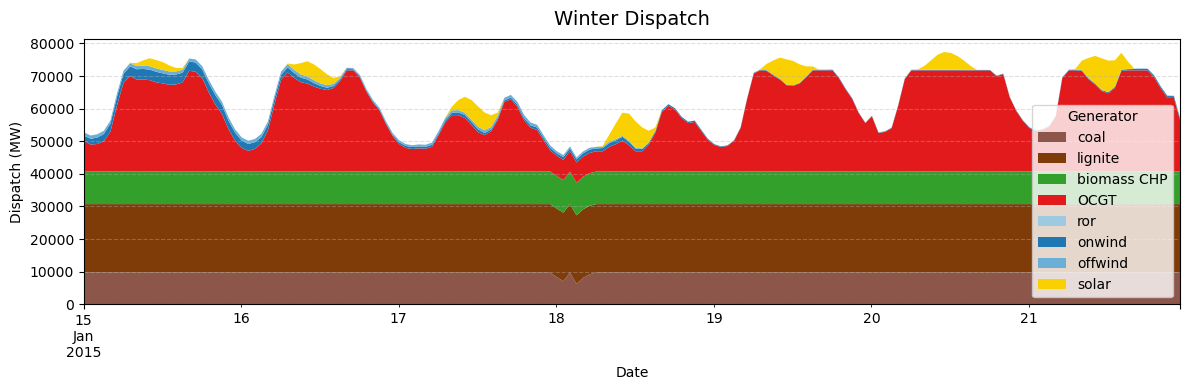

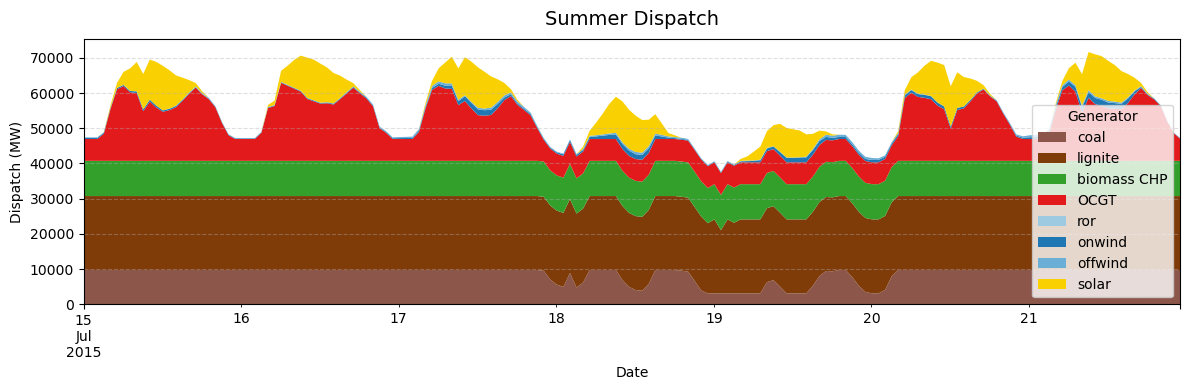

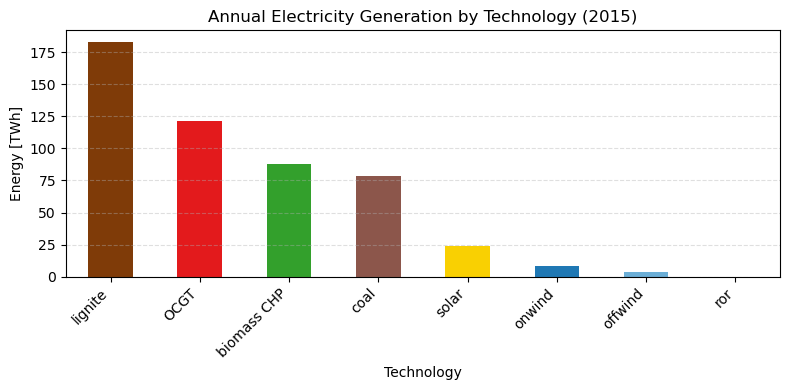

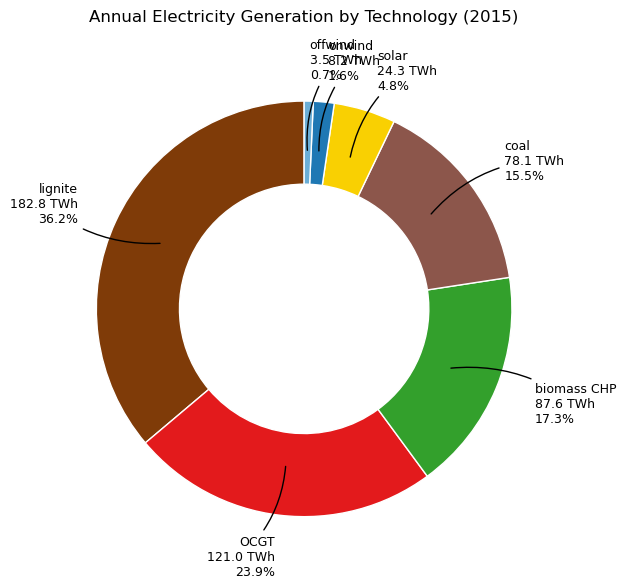

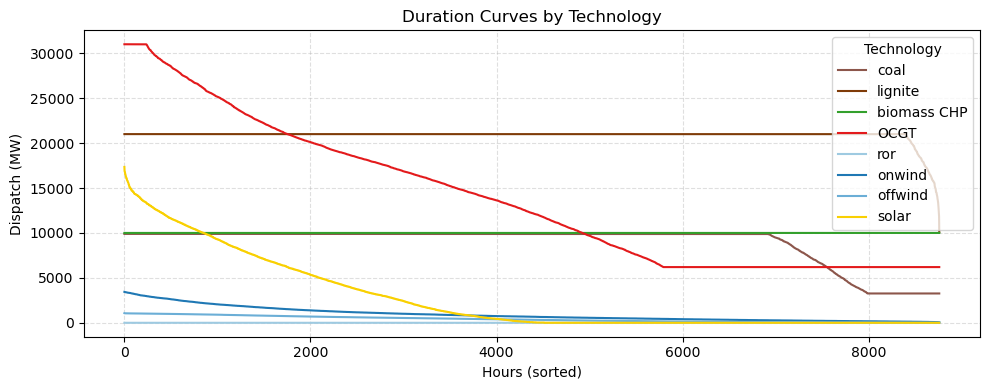

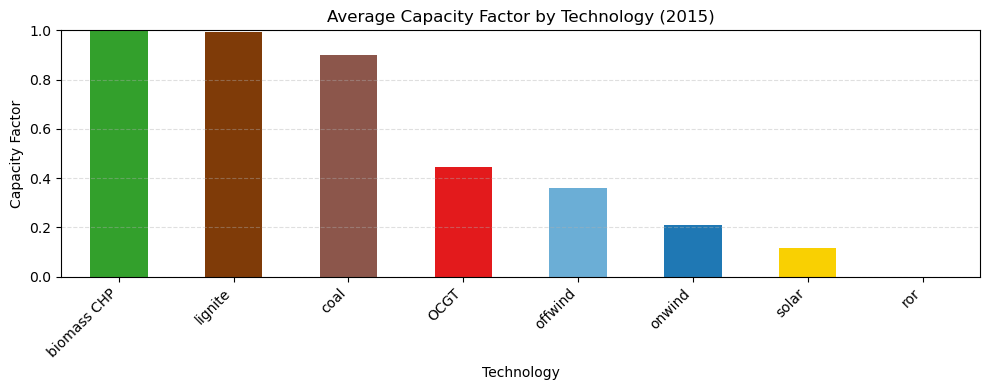

In [14]:
print_summary(n_batt_store)
# Plot winter week
plot_dispatch_week(n_batt_store, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
plot_dispatch_week(n_batt_store,"2015-07-15", "2015-07-21", "Summer Dispatch")
plot_generation_bar(n_batt_store)
plot_generation_pie(n_batt_store)
plot_duration_curves(n_batt_store)
plot_capacity_factors(n_batt_store)

In [15]:
n_batt_store.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
Link,,,,,,,,,,,,,,,,,,,,,
grid to battergy storage,DEU_elec,elec_store,,AC,0.955,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,4133.844280
battery storage to grid,elec_store,DEU_elec,,battery storage,0.955,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,5185.236246


In [16]:
n_batt_store.stores

,bus,type,carrier,e_nom,e_nom_mod,e_nom_extendable,e_nom_min,e_nom_max,e_min_pu,e_max_pu,...,sign,marginal_cost,marginal_cost_quadratic,marginal_cost_storage,capital_cost,standing_loss,active,build_year,lifetime,e_nom_opt
Store,,,,,,,,,,,,,,,,,,,,,
Battery Storage Store,elec_store,,battery storage,0.0,0.0,True,0.0,inf,0.0,1.0,...,1.0,0.0,0.0,0.0,17718.354182,0.0,True,0,inf,11748.25862


<Axes: xlabel='snapshot', ylabel='battery'>

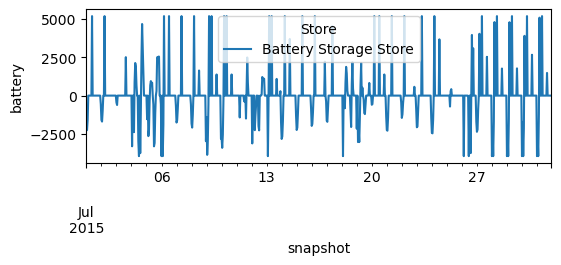

In [17]:
n_batt_store.stores_t.p.loc["2015-07"].plot(figsize=(6, 2), ylabel="battery")

<Axes: xlabel='snapshot', ylabel='battery'>

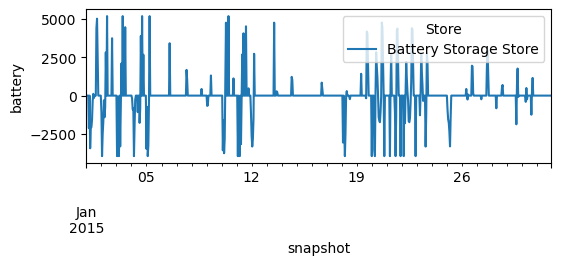

In [18]:
n_batt_store.stores_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="battery")

### Adding Hydrogen Storage as Store with Links

In [19]:
n_H_store = base.build_network(solve=False)

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


In [20]:
#Create a new carrier
n_H_store.add("Carrier",
              "H2")

#Create a new bus
n_H_store.add("Bus",
          "H2",
          carrier = "H2",
          overwrite=True)

#Connect the store to the bus
n_H_store.add("Store",
          "H2 Tank",
          bus = "H2",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = annuity(25, 0.07)*57000*(1+0.011),
          overwrite=True)

n_H_store.add("Link",
          "H2 Electrolysis",
          bus0 = f"{country}_elec",
          bus1 = "H2",
          p_nom_extendable = True,
          efficiency = 0.8,
          capital_cost = annuity(25, 0.07)*600000*(1+0.05),
          overwrite=True)

#Add the link "H2 Fuel Cell" that transports energy from the H2 bus (bus0) to the electricity bus (bus1)
#with 58% efficiency
n_H_store.add("Link",
          "H2 Fuel Cell",
          bus0 = "H2",
          bus1 = f"{country}_elec",
          p_nom_extendable = True,
          efficiency = 0.58,
          capital_cost = annuity(10, 0.07)*1300000*(1+0.05),
          overwrite=True)

Index(['H2 Fuel Cell'], dtype='object')

In [21]:
n_H_store.optimize(solver_name="gurobi")

Index(['H2 Electrolysis'], dtype='object', name='Link')
Index(['DEU_elec'], dtype='object', name='Bus')


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 62.64it/s]
INFO:linopy.io: Writing time: 0.79s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2625590


...

Solved in 43320 iterations and 3.04 seconds (3.63 work units)


INFO:gurobipy:Solved in 43320 iterations and 3.04 seconds (3.63 work units)


Optimal objective  3.188824739e+10


INFO:gurobipy:Optimal objective  3.188824739e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105131 primals, 219016 duals
Objective: 3.19e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

System Cost: 31.89 billion euros

Optimal Generator and Storage Capacities (GW):
coal           14.898778
lignite        21.000000
biomass CHP    10.000000
OCGT           31.000000
ror             0.000000
onwind          0.000000
offwind         2.685846
solar           0.000000
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
coal           111.236920
lignite        182.258414
biomass CHP     87.600000
OCGT           115.708797
ror              0.000000
onwind           0.000000
offwind          8.460432
solar            0.000000
dtype: float64


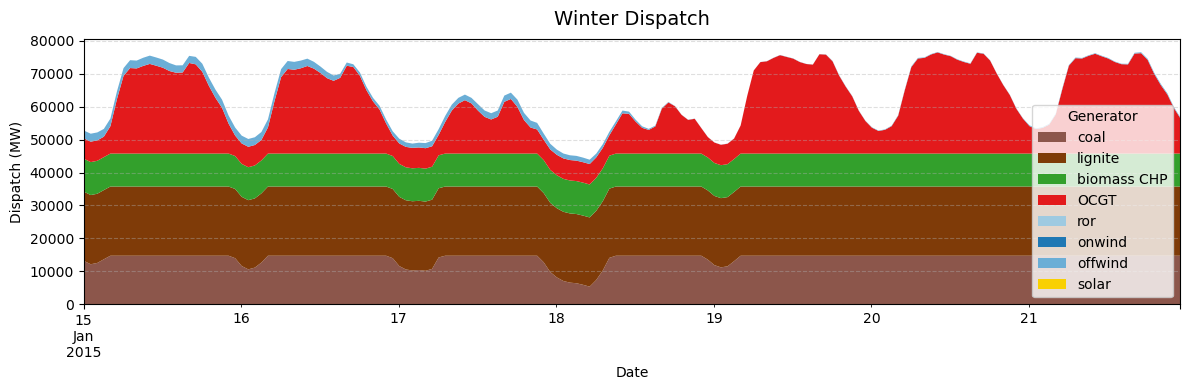

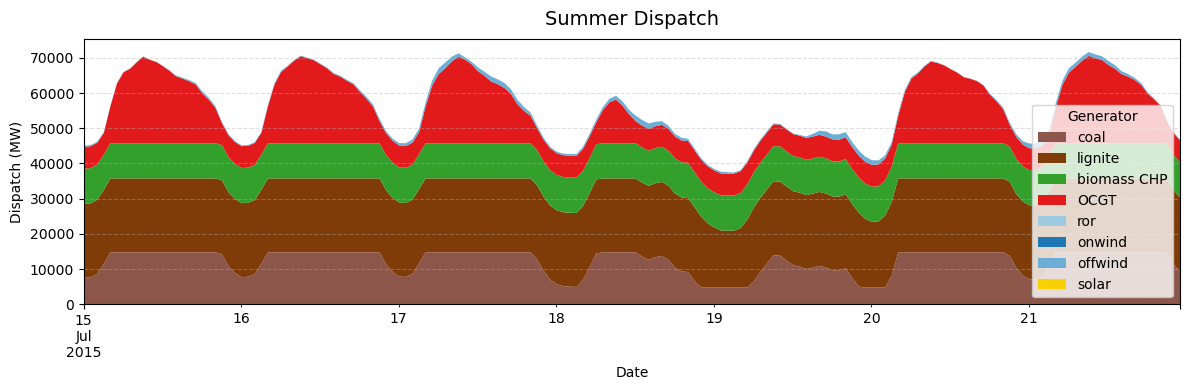

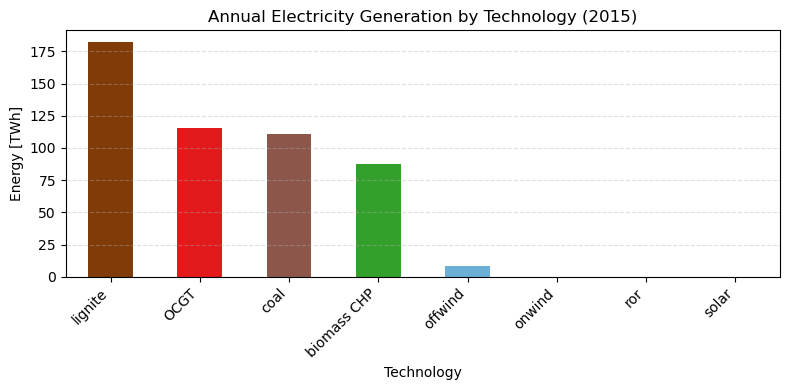

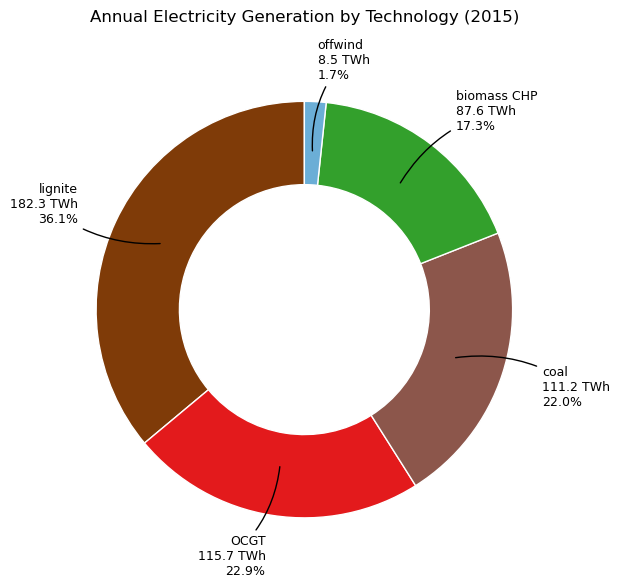

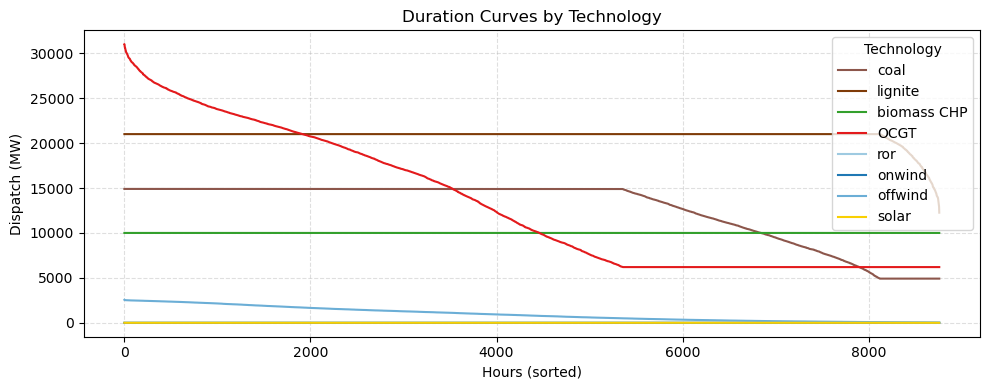

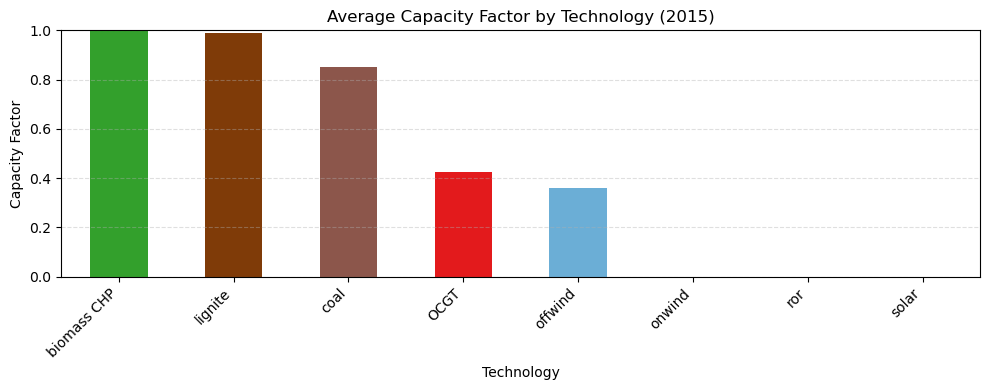

In [22]:
print_summary(n_H_store)
# Plot winter week
plot_dispatch_week(n_H_store, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
plot_dispatch_week(n_H_store,"2015-07-15", "2015-07-21", "Summer Dispatch")
plot_generation_bar(n_H_store)
plot_generation_pie(n_H_store)
plot_duration_curves(n_H_store)
plot_capacity_factors(n_H_store)